In [13]:
pip install gwaslab 


Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [14]:
import gwaslab as gl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
import pandas as pd
import gzip

file_path = "../data/21001_raw.gwas.imputed_v3.both_sexes.tsv.bgz"
with gzip.open(file_path, 'rt') as f:
    df = pd.read_csv(f, sep='\t') 


In [4]:
df.head()


,variant,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,pval
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342


In [5]:
df['CHR'] = df['variant'].str.split(':').str[0]
df['POS'] = df['variant'].str.split(':').str[1]
df['A2']=df['variant'].str.split(':').str[2]
df['A1']=df['variant'].str.split(':').str[3]



In [6]:
df.shape

(13791467, 15)

In [7]:
df=df.rename(columns={'variant':'SNPID', 'pval':'P'})
minor_df=df[df['minor_AF'] > 0.05]
minor_df = minor_df[~minor_df['SNPID'].str.startswith('X:')]
minor_df.head()



,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS,A2,A1
4,1:692794:CA:C,C,0.110590,False,359983,79621.1,2179000.0,-0.016436,0.019585,-0.839228,0.401342,1,692794,CA,C
5,1:693731:A:G,G,0.115767,False,359983,83348.0,2281760.0,-0.004255,0.018507,-0.229918,0.818155,1,693731,A,G
6,1:707522:G:C,C,0.097255,False,359983,70020.6,1916410.0,-0.010428,0.020804,-0.501258,0.616190,1,707522,G,C
9,1:730087:T:C,C,0.056424,False,359983,40623.1,1110650.0,-0.047388,0.025783,-1.837930,0.066074,1,730087,T,C
10,1:731718:T:C,C,0.121670,False,359983,87598.4,2397990.0,-0.005842,0.017552,-0.332853,0.739246,1,731718,T,C


In [ ]:
processed_df_csv=minor_df.to_csv("processed_df.csv", sep=" ", index=False)


Processed File

In [16]:
import pandas as pd 
df = pd.read_csv("processed_df.csv", delim_whitespace=True)

/tmp/ipykernel_3205485/1352686489.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("processed_df.csv", delim_whitespace=True)


In [13]:
df.rename(columns={
    'SNPID': 'SNP',
    'A1': 'A1',
    'A2': 'A2',
    'minor_AF': 'freq',
    'beta': 'b',
    'se': 'se',
    'P': 'p',
    'n_complete_samples': 'N'
}, inplace=True)


extracted_columns = ['SNP', 'A1', 'A2', 'freq', 'b', 'se', 'p', 'N']
df_extracted = df[extracted_columns]
df_extracted.head()
cojo_df=df_extracted.to_csv("cojo_extracted_file.csv", sep=" ", index=False)


In [14]:
df_extracted.head()

,SNP,A1,A2,freq,b,se,p,N
0,1:692794:CA:C,C,CA,0.110590,-0.016436,0.019585,0.401342,359983
1,1:693731:A:G,G,A,0.115767,-0.004255,0.018507,0.818155,359983
2,1:707522:G:C,C,G,0.097255,-0.010428,0.020804,0.616190,359983
3,1:730087:T:C,C,T,0.056424,-0.047388,0.025783,0.066074,359983
4,1:731718:T:C,C,T,0.121670,-0.005842,0.017552,0.739246,359983


Tested cojo snps

In [17]:
df_tested_cojo_snps = pd.read_csv("../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)

/tmp/ipykernel_3205485/311340159.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_tested_cojo_snps = pd.read_csv("../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)


In [18]:
df_tested_cojo_snps.head()

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
0,16,16:209764:G:C,209764,C,0.173538,-0.021170,0.014718,1.503410e-01,361237,0.168986,-1.406950,0.018339,0.000000e+00,0.070327
1,16,16:406427:G:C,406427,C,0.355430,-0.080681,0.011680,4.931170e-12,359053,0.310139,-1.574420,0.016174,0.000000e+00,0.045560
2,16,16:782397:C:T,782397,T,0.238811,0.012140,0.013152,3.559810e-01,356967,0.218688,1.313190,0.016386,0.000000e+00,0.084925
3,16,16:931605:G:C,931605,C,0.074670,-0.048957,0.021191,2.087260e-02,361723,0.073559,-2.931640,0.030100,0.000000e+00,0.016078
4,16,16:1063319:G:A,1063319,A,0.077376,-0.010060,0.020961,6.312490e-01,357842,0.067594,0.136596,0.022845,2.241920e-09,0.046316


In [ ]:
import gwaslab as gl
sumstats=gl.Sumstats(df_tested_cojo_snps, snpid='SNP', beta="beta", se="se", pos="POS")



2025/02/17 08:04:52 GWASLab v3.5.5 https://cloufield.github.io/gwaslab/
2025/02/17 08:04:52 (C) 2022-2025, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2025/02/17 08:04:52 Start to initialize gl.Sumstats from file :gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo
2025/02/17 08:04:52  -Reading columns          : 
2025/02/17 08:04:52  -Renaming columns to      : 
2025/02/17 08:04:52  -Current Dataframe shape : 0  x  0
2025/02/17 08:04:52  -Initiating a status column: STATUS ...
2025/02/17 08:04:52  #WARNING! Version of genomic coordinates is unknown...
2025/02/17 08:04:52 Start to reorder the columns...v3.5.5
2025/02/17 08:04:52  -Current Dataframe shape : 0 x 1 ; Memory usage: 21.47 MB
2025/02/17 08:04:52  -Reordering columns to    : STATUS
2025/02/17 08:04:52 Finished reordering the columns.
2025/02/17 08:04:52  -Column  : STATUS  
2025/02/17 08:04:52  -DType   : category
2025/02/17 08:04:52  -Verified: T       
2025/02/17 08:04:53  -Current Dataframe memory usage: 21

In [ ]:
# sumstats.data

,STATUS


In [ ]:
# sumstats.data.to_csv("cojo_sumststs.txt", sep="\t",index=None)


In [ ]:
# sumstats=pd.read_csv("cojo_sumststs.txt", sep="\t", header=None)
# sumstats.head()

/tmp/ipykernel_467848/3578967730.py:1: DtypeWarning: Columns (1,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  sumstats=pd.read_csv("cojo_sumststs.txt", sep="\t", header=None)


,0,1,2,3,4,5,6
0,SNPID,POS,EA,NEA,BETA,SE,STATUS
1,1:692794:CA:C,692794,CA,C,-0.0164361,0.0195848,9999999
2,1:693731:A:G,693731,A,G,-0.00425518,0.0185074,9999999
3,1:707522:G:C,707522,G,C,-0.0104283,0.0208043,9999999
4,1:730087:T:C,730087,T,C,-0.0473876,0.0257832,9999999


In [ ]:
# sumstats.plot_mqq(skip=2,anno=True)

In [ ]:
# sumstats.plot_mqq(mode="r", anno=True, region=(1, 110232801, 151018861), region_grid=True, build='hg19')



In [ ]:
# variant_position = 53767042
# start_pos= variant_position- 100000
# end_pos= variant_position +100000

In [ ]:
# locus = sumstats.filter_value(f'CHR==16 & POS>{start_pos} & POS<{end_pos}')
# print(locus.data.shape)


In [ ]:

# df_extracted.fill_data(to_fill=["BETA"])
# df_extracted.head()


In [ ]:
# df_locus_zoom=df[["SNPID", "CHR", "POS","P"]]
# df_locus_zoom.head()
# df_locus_zoom['BP']=df['POS']
# df_locus_zoom=df[["SNPID", "CHR", "POS","P"]]
# df_locus_zoom.to_csv("../notebooksdf_locus_zoom.csv")



In [19]:
import pandas as pd 
df_tested_cojo_snps = pd.read_csv("../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)

/tmp/ipykernel_3205485/2037371449.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_tested_cojo_snps = pd.read_csv("../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)


In [20]:
df_tested_cojo_snps.head()

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
0,16,16:209764:G:C,209764,C,0.173538,-0.021170,0.014718,1.503410e-01,361237,0.168986,-1.406950,0.018339,0.000000e+00,0.070327
1,16,16:406427:G:C,406427,C,0.355430,-0.080681,0.011680,4.931170e-12,359053,0.310139,-1.574420,0.016174,0.000000e+00,0.045560
2,16,16:782397:C:T,782397,T,0.238811,0.012140,0.013152,3.559810e-01,356967,0.218688,1.313190,0.016386,0.000000e+00,0.084925
3,16,16:931605:G:C,931605,C,0.074670,-0.048957,0.021191,2.087260e-02,361723,0.073559,-2.931640,0.030100,0.000000e+00,0.016078
4,16,16:1063319:G:A,1063319,A,0.077376,-0.010060,0.020961,6.312490e-01,357842,0.067594,0.136596,0.022845,2.241920e-09,0.046316


In [31]:
df_tested_cojo_snps["SNP"].to_csv("../data/snplist/cojo_sig_locus.snplist.txt",sep=" ",index=None,header=None)


In [ ]:
# df["SNPID"].head()
# df["SNPID"].to_csv("../data/snplist/plot_sig_locs.snplist.txt",sep="\t",index=None,header=None)

# df["SNPID"].shape


(433,)

In [ ]:
# df = df.head(429)
# df.shape

(429, 10)

In [21]:
!plink \
  --bfile "../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/plot_chr16_eur/chr16_eur" \
  --keep-allele-order \
  --r square \
  --extract ../data/snplist/cojo_sig_locus.snplist.txt \
  --out ../data/plot_ld/cojo_sig_locus_mt

!plink \
  --bfile "../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/plot_chr16_eur/chr16_eur" \
  --keep-allele-order \
  --r2 square \
  --extract ../data/snplist/cojo_sig_locus.snplist.txt \
  --out ../data/plot_ld/cojo_sig_locus_mt_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/plot_ld/cojo_sig_locus_mt.log.
Options in effect:
  --bfile ../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/plot_chr16_eur/chr16_eur
  --extract ../data/snplist/cojo_sig_locus.snplist.txt
  --keep-allele-order
  --out ../data/plot_ld/cojo_sig_locus_mt
  --r square

257418 MB RAM detected; reserving 128709 MB for main workspace.
2697949 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../data/plot_ld/cojo_sig_locus_mt.nosex .
--extract: 180 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465666768697071727

In [9]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
numpy2ri.activate()
pandas2ri.activate()

In [10]:
susieR = importr('susieR')

In [22]:

ld = pd.read_csv("../data/plot_ld/cojo_sig_locus_mt.ld", sep="\t", header=None)
R_df = ld.values
ld2 = pd.read_csv("../data/plot_ld/cojo_sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(180, 180)

In [154]:
R_df_trimmed = R_df[:, :180]

In [155]:
R_df_trimmed.shape

(180, 180)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

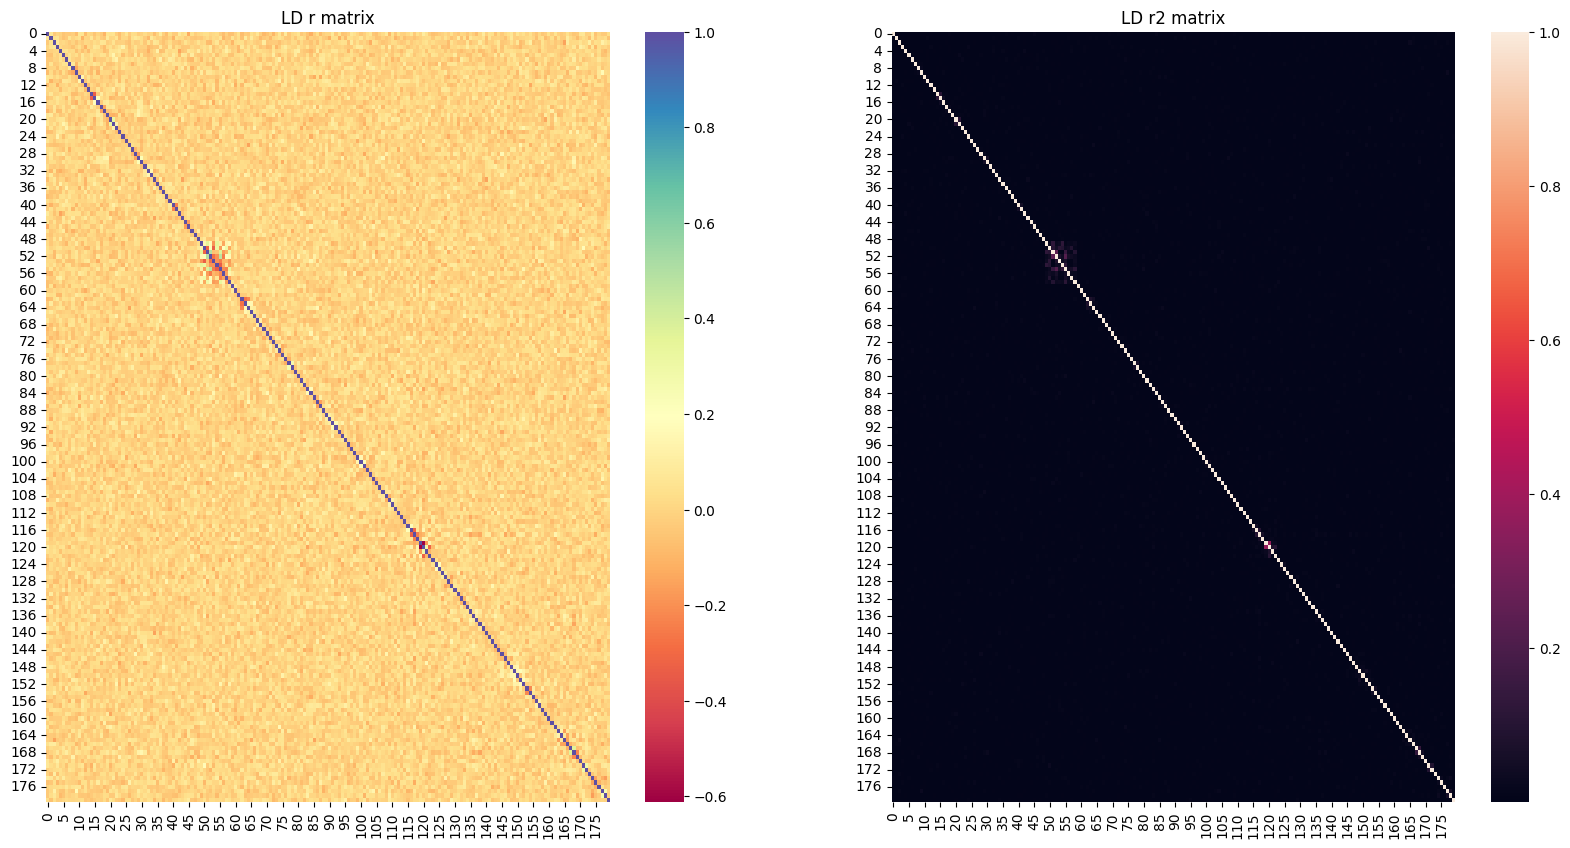

In [23]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [24]:
df_tested_cojo_snps = pd.read_csv("../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)

/tmp/ipykernel_3205485/311340159.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_tested_cojo_snps = pd.read_csv("../notebooks/gcta-1.94.3-linux-kernel-3-x86_64/tes_chr16.jma.cojo", delim_whitespace=True)


In [25]:
df_tested_cojo_snps.head(3)

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
0,16,16:209764:G:C,209764,C,0.173538,-0.021170,0.014718,1.503410e-01,361237,0.168986,-1.40695,0.018339,0.0,0.070327
1,16,16:406427:G:C,406427,C,0.355430,-0.080681,0.011680,4.931170e-12,359053,0.310139,-1.57442,0.016174,0.0,0.045560
2,16,16:782397:C:T,782397,T,0.238811,0.012140,0.013152,3.559810e-01,356967,0.218688,1.31319,0.016386,0.0,0.084925


In [ ]:
# bhat = df_tested_cojo_snps["b"].values.reshape(180, 1)
# shat = df_tested_cojo_snps["se"].values.reshape(180, 1)

# print(bhat.shape)  # Should be (180, 1)
# print(shat.shape)  # Should be (180, 1)


(180, 1)
(180, 1)


In [ ]:
# import rpy2.robjects as ro
# import numpy as np


# R_r = ro.r['matrix'](np.array(R_df_trimmed).flatten(), nrow=R_df_trimmed.shape[0], ncol=R_df_trimmed.shape[1])



NameError: name 'R_df_trimmed' is not defined

In [27]:
ro.r('set.seed(123)')
fit = susieR.susie_rss(
    bhat = df_tested_cojo_snps["b"].values.reshape(len(R_df), 1),
    shat = df_tested_cojo_snps["se"].values.reshape(len(R_df), 1),
    R = R_df,
    L = 10,
    n = 503
)

In [28]:

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)
print(credible_sets)

$cs
$cs$L1
[1] 118

$cs$L2
[1] 97

$cs$L3
[1] 96

$cs$L4
[1] 98

$cs$L5
[1] 95

$cs$L6
[1] 18

$cs$L7
[1] 105

$cs$L8
[1] 21

$cs$L9
[1] 147


$purity
   min.abs.corr mean.abs.corr median.abs.corr
L1            1             1               1
L2            1             1               1
L3            1             1               1
L4            1             1               1
L5            1             1               1
L6            1             1               1
L7            1             1               1
L8            1             1               1
L9            1             1               1

$cs_index
[1] 1 2 3 4 5 6 7 8 9

$coverage
[1] 1.0000000 1.0000000 1.0000000 0.9999990 0.9999864 1.0000000 0.9999995
[8] 0.9995016 0.9998708

$requested_coverage
[1] 0.95




In [ ]:
R_df_trimmed.shape

(180, 180)

In [29]:

df_tested_cojo_snps["cs"] = 0
n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]

for i in range(n_cs):
    cs_index = credible_sets[i]
    df_tested_cojo_snps.loc[np.array(cs_index)-1, "cs"] = i + 1

df_tested_cojo_snps["pip"] = np.array(susieR.susie_get_pip(fit))
df_tested_cojo_snps

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r,cs,pip
0,16,16:209764:G:C,209764,C,0.173538,-0.021170,0.014718,1.503410e-01,361237,0.168986,-1.406950,0.018339,0.000000e+00,0.070327,0,3.563816e-14
1,16,16:406427:G:C,406427,C,0.355430,-0.080681,0.011680,4.931170e-12,359053,0.310139,-1.574420,0.016174,0.000000e+00,0.045560,0,3.657974e-11
2,16,16:782397:C:T,782397,T,0.238811,0.012140,0.013152,3.559810e-01,356967,0.218688,1.313190,0.016386,0.000000e+00,0.084925,0,5.213607e-13
3,16,16:931605:G:C,931605,C,0.074670,-0.048957,0.021191,2.087260e-02,361723,0.073559,-2.931640,0.030100,0.000000e+00,0.016078,0,1.743050e-13
4,16,16:1063319:G:A,1063319,A,0.077376,-0.010060,0.020961,6.312490e-01,357842,0.067594,0.136596,0.022845,2.241920e-09,0.046316,0,1.122435e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,16,16:69942368:T:TA,69942368,TA,0.065122,-0.041314,0.022852,7.062120e-02,353026,0.058648,-1.255260,0.025694,0.000000e+00,-0.120466,0,4.063416e-14
176,16,16:70368909:G:A,70368909,A,0.116714,-0.090113,0.017355,2.077710e-07,361420,0.112326,-0.969185,0.019050,0.000000e+00,-0.057807,0,6.781131e-06
177,16,16:72194325:T:C,72194325,C,0.478183,0.047949,0.011202,1.866400e-05,358420,0.514911,0.074413,0.011844,3.327300e-10,-0.249064,0,2.196351e-08
178,16,16:72447253:A:G,72447253,G,0.077731,-0.082924,0.020890,7.199410e-05,358747,0.069583,-0.491101,0.022469,6.665490e-106,-0.012923,0,1.139970e-09


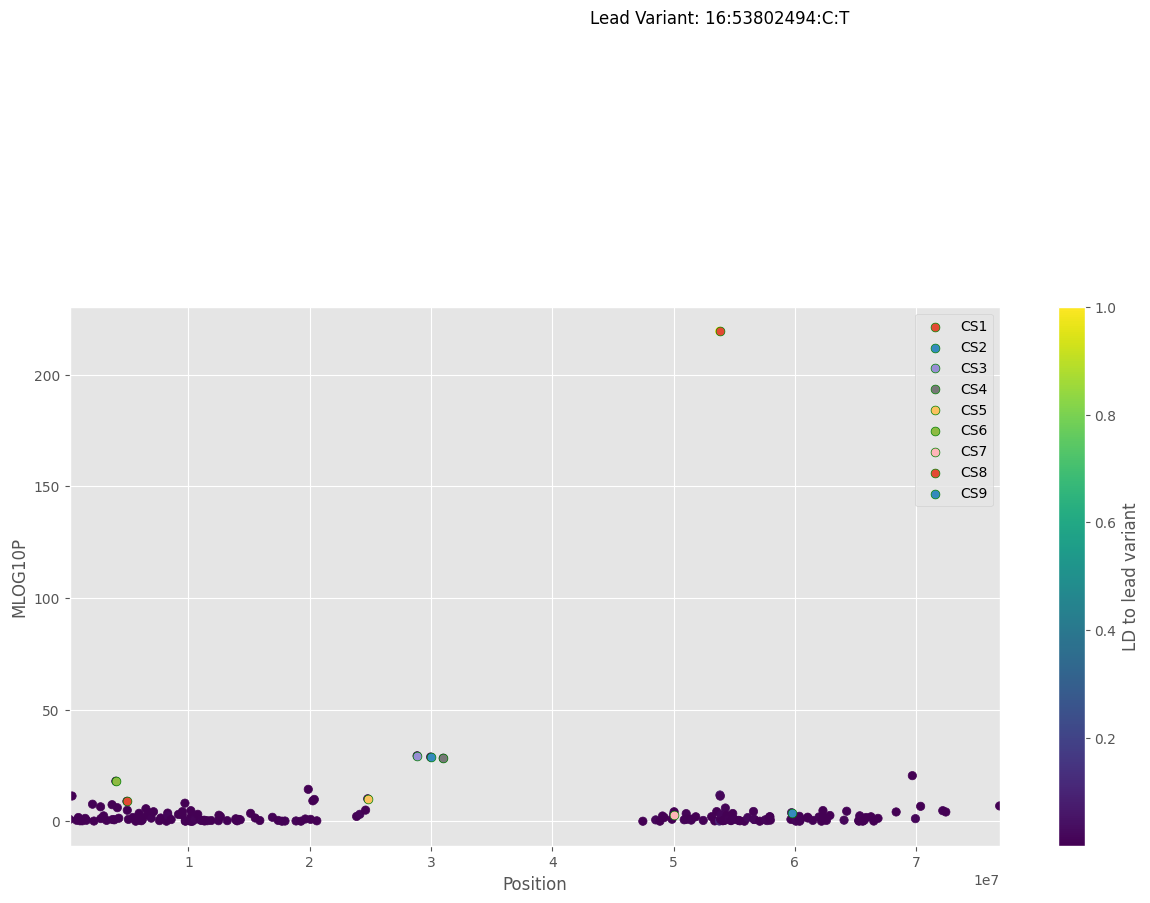

In [132]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "MLOG10P"
df_tested_cojo_snps[col_to_plot] = -np.log10(df_tested_cojo_snps["p"])

# Plot the variants with their LD score to the lead variant
p = ax.scatter(df_tested_cojo_snps["bp"], df_tested_cojo_snps[col_to_plot], c=ld2[df_tested_cojo_snps["p"].idxmin()])

# Show the lead variant
lead_x, lead_y = df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), "bp"], df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df_tested_cojo_snps.loc[df_tested_cojo_snps['p'].idxmin(), 'SNP']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)

# Plot circles around variants in credible sets
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df_tested_cojo_snps.loc[np.array(cs_index)-1, "bp"]
    y = df_tested_cojo_snps.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)

# Set x-limits dynamically
ax.set_xlim((df_tested_cojo_snps["bp"].min(), df_tested_cojo_snps["bp"].max()))

# Show the legend
plt.legend()

# Display the plot
plt.show()


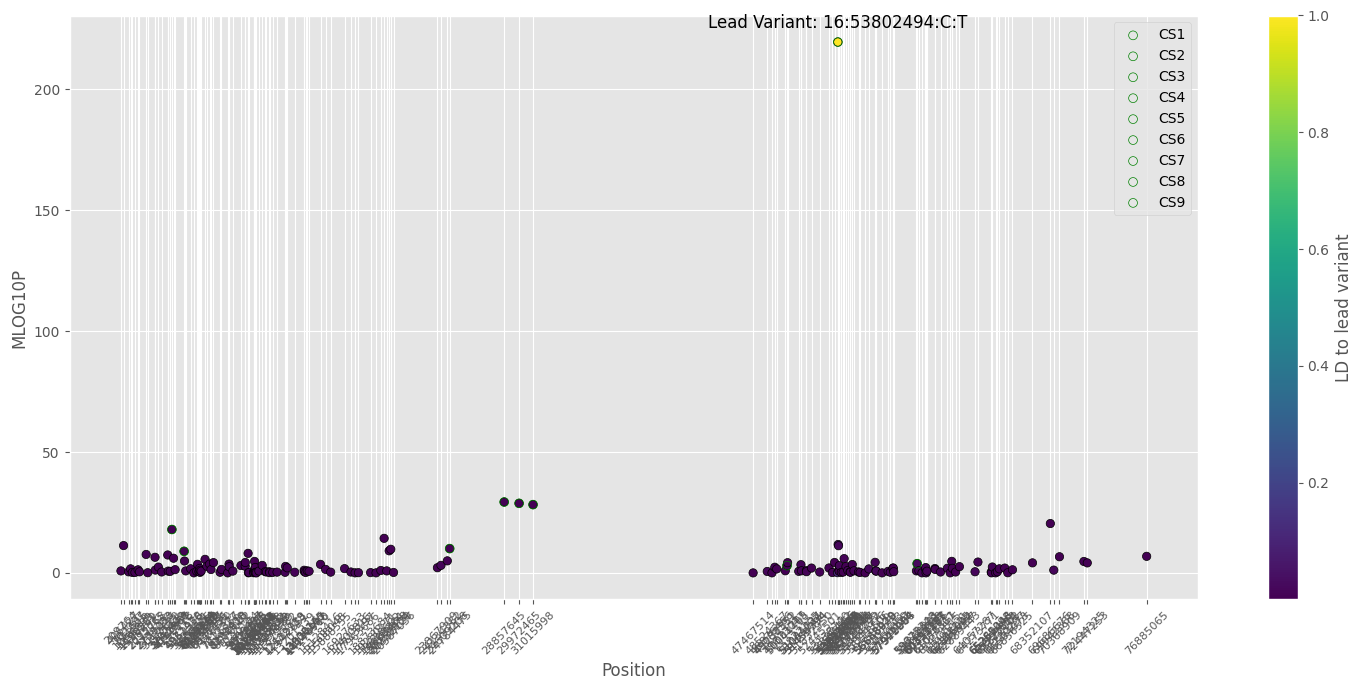

In [30]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "MLOG10P"
df_tested_cojo_snps[col_to_plot] = -np.log10(df_tested_cojo_snps["p"])

lead_idx = df_tested_cojo_snps["p"].idxmin()
p = ax.scatter(df_tested_cojo_snps["bp"], df_tested_cojo_snps[col_to_plot], c=ld2[lead_idx], cmap="viridis", edgecolor="black")

lead_x, lead_y = df_tested_cojo_snps.loc[lead_idx, "bp"], df_tested_cojo_snps.loc[lead_idx, col_to_plot]
ax.annotate(f"Lead Variant: {df_tested_cojo_snps.loc[lead_idx, 'SNP']}", (lead_x, lead_y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=12)

for i, cs_index in enumerate(credible_sets):
    pos = df_tested_cojo_snps.loc[np.array(cs_index) - 1, "bp"]
    y = df_tested_cojo_snps.loc[np.array(cs_index) - 1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green", facecolors='none')

plt.colorbar(p, label="LD to lead variant")

ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)

x_positions = df_tested_cojo_snps["bp"].values
ax.set_xticks(x_positions)
ax.set_xticklabels(x_positions, rotation=45, fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()


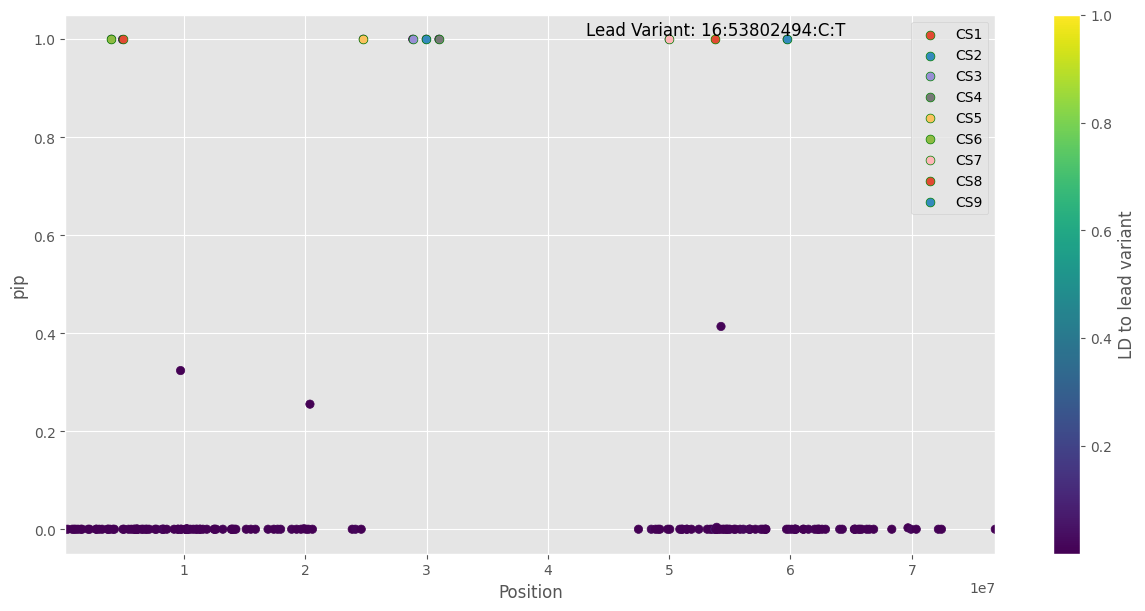

In [122]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "pip"
p = ax.scatter(df_tested_cojo_snps["bp"], df_tested_cojo_snps[col_to_plot], c=ld2[df_tested_cojo_snps["p"].idxmin()])

# Show the lead variant
lead_x, lead_y = df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), "bp"], df_tested_cojo_snps.loc[df_tested_cojo_snps["p"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df_tested_cojo_snps.loc[df_tested_cojo_snps['p'].idxmin(), 'SNP']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)

# Plot circles around variants in credible sets
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df_tested_cojo_snps.loc[np.array(cs_index)-1, "bp"]
    y = df_tested_cojo_snps.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)

# Set x-limits
ax.set_xlim((df_tested_cojo_snps["bp"].min(), df_tested_cojo_snps["bp"].max()))

# Show the legend
plt.legend()

# Display the plot
plt.show()


In [135]:
cs_index = np.array(credible_sets[0])
for i in range(1, n_cs):
    cs_index = np.concatenate((cs_index, np.array(credible_sets[i])), axis=0)
# cs_index = np.array(cs_index).flatten()
credible_snps_df = df_tested_cojo_snps.loc[cs_index - 1, :]
credible_snps_df

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r,cs,pip,MLOG10P
117,16,16:53802494:C:T,53802494,T,0.402018,0.359699,0.011353,2.721410e-220,361202,0.432406,3.731550,0.028565,0.000000e+00,-0.244688,1,1.000000,219.565206
96,16,16:29972465:C:CA,29972465,CA,0.416972,0.133687,0.011854,1.692900e-29,328416,0.400596,0.084194,0.011964,1.955540e-12,-0.079349,2,1.000000,28.771369
95,16,16:28857645:A:G,28857645,G,0.405474,0.129342,0.011357,4.752350e-30,360848,0.341948,0.450490,0.011708,0.000000e+00,-0.007375,3,1.000000,29.323092
97,16,16:31015998:TA:T,31015998,T,0.422060,-0.133416,0.011945,5.746080e-29,322378,0.426441,-0.211178,0.012115,4.794930e-68,0.000000,4,0.999999,28.240628
94,16,16:24784475:C:T,24784475,T,0.266780,-0.081700,0.012596,8.793230e-11,361619,0.267396,-0.187370,0.012968,2.558410e-47,0.064415,5,0.999986,10.055852
17,16,16:4017567:T:A,4017567,A,0.402887,0.102464,0.011614,1.119770e-18,345806,0.590457,2.199040,0.019079,0.000000e+00,0.157249,6,1.000000,17.950871
104,16,16:50001765:G:GTACCACCAGCGAAGC,50001765,GTACCACCAGCGAAGC,0.338271,-0.040555,0.012310,9.865720e-04,330849,0.300199,-0.744082,0.013759,0.000000e+00,-0.085341,7,0.999999,3.005871
20,16,16:4932470:G:A,4932470,A,0.437222,-0.068619,0.011281,1.179990e-09,358421,0.536779,-2.113570,0.019150,0.000000e+00,-0.328859,8,0.999502,8.928122
146,16,16:59728623:C:T,59728623,T,0.173120,0.056450,0.014895,1.506800e-04,353397,0.167992,1.617920,0.019572,0.000000e+00,-0.055633,9,0.999871,3.821944


In [64]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
numpy2ri.activate()
pandas2ri.activate()

In [ ]:
susieR = importr('susieR')

In [ ]:
#Load LD data
ld = pd.read_csv("../data/ld/plot_sig_locus_mt.ld", sep="\t", header=None)
R_df = ld.values
ld2 = pd.read_csv("../data/ld/plot_sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(429, 429)

In [ ]:
ld2.shape

(429, 429)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

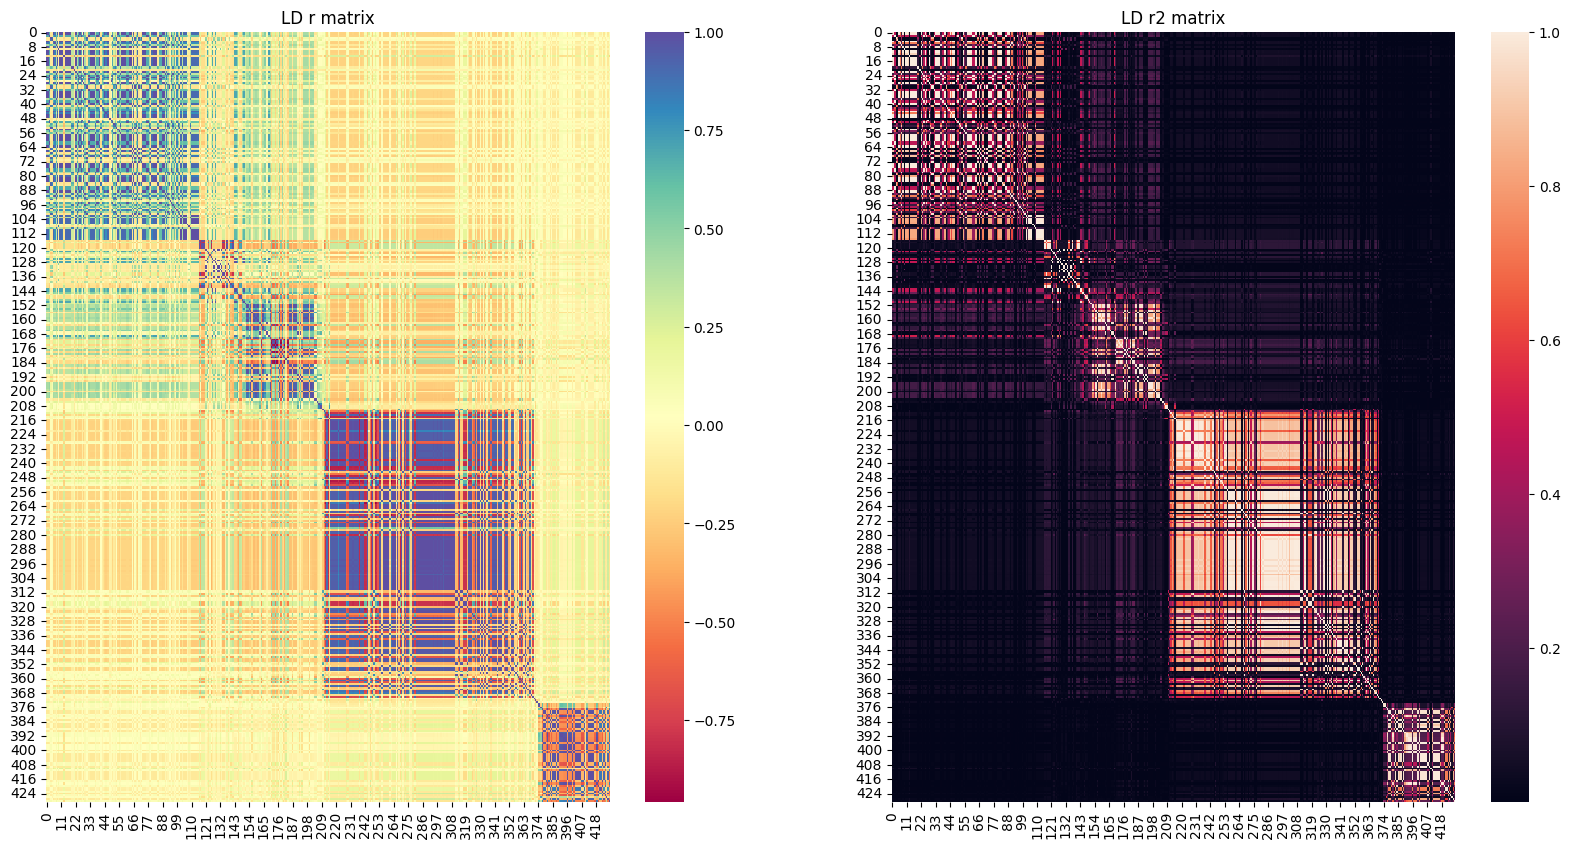

In [ ]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [ ]:
df["SE"].head()

11445981    0.023980
11445982    0.024041
11445983    0.016988
11445984    0.016279
11445985    0.017996
Name: SE, dtype: float64

In [ ]:
print(df["BETA"].shape)  # Should match len(R_df)
print(df["SE"].shape)    # Should match len(R_df)
print(R_df.shape)        # Should be (N, N) where N = len(df["BETA"])


(433,)
(433,)
(429, 429)


In [ ]:
num_snps = R_df.shape[0]  # 429

fit = susieR.susie_rss(
    bhat=df["BETA"].values[:num_snps].reshape(num_snps, 1),
    shat=df["SE"].values[:num_snps].reshape(num_snps, 1),
    R=R_df,
    L=10,
    n=503
)


429


In [ ]:
print(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df))

we have 9 crediable sets(n_cs)


In [ ]:
df["cs"] = 0
df = df.head(429)
df = df.head(429).reset_index(drop=True)

n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
for i in range(n_cs):
    df = df.reset_index(drop=True)
    cs_index = credible_sets[i]
    df.loc[np.array(cs_index)-1, "cs"] = i + 1

df["pip"] = np.array(susieR.susie_get_pip(fit))
df


# pip_values = np.array(susieR.susie_get_pip(fit))
# # pip_values_shape=pip_values[:len(df)]
# # pip_values_shape




NameError: name 'df' is not defined

,SNPID,CHR,POS,EA,NEA,EAF,BETA,SE,P,STATUS,MLOG10P
0,16:53668070:C:CA,16,53668070,CA,C,0.057727,-0.082986,0.023980,5.388460e-04,9999999,3.268535
1,16:53668214:T:G,16,53668214,G,T,0.057073,-0.085331,0.024041,3.862680e-04,9999999,3.413111
2,16:53668575:C:G,16,53668575,G,C,0.122528,-0.062887,0.016988,2.140590e-04,9999999,3.669467
3,16:53668653:C:T,16,53668653,T,C,0.135920,0.105392,0.016279,9.549190e-11,9999999,10.020033
4,16:53669178:A:T,16,53669178,T,A,0.108305,0.103681,0.017996,8.350220e-09,9999999,8.078302


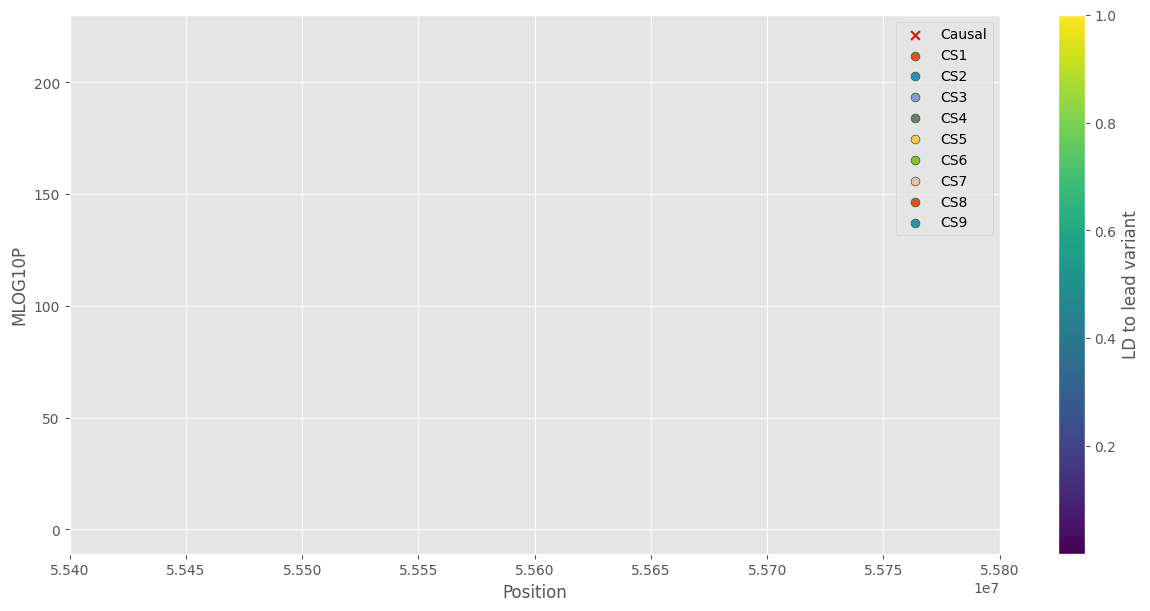

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))
col_to_plot = "MLOG10P"
df[col_to_plot] = -np.log10(df["P"])
#plot the variants with their LD score to the lead variant
p=ax.scatter(df["POS"], df[col_to_plot], c=ld2[df["P"].idxmin()])
#show the lead variant
lead_x, lead_y = df.loc[df["P"].idxmin(), "POS"], df.loc[df["P"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df.loc[df['P'].idxmin(), 'SNPID']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)

#plot the causal variant
ax.scatter(df.loc[(df["CHR"]==2)&(df["POS"]==55620927),"POS"],df.loc[(df["CHR"]==2)&(df["POS"]==55620927),col_to_plot],
           marker='x',s=40,c="red",label="Causal")

#plot circles around variants in credible sets
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df.loc[np.array(cs_index)-1, "POS"]
    y = df.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")



plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((55400000, 55800000))
plt.legend()
plt.show()

In [ ]:
df["P"]= pip_values

ValueError: Length of values (429) does not match length of index (433)

KeyError: 11446510

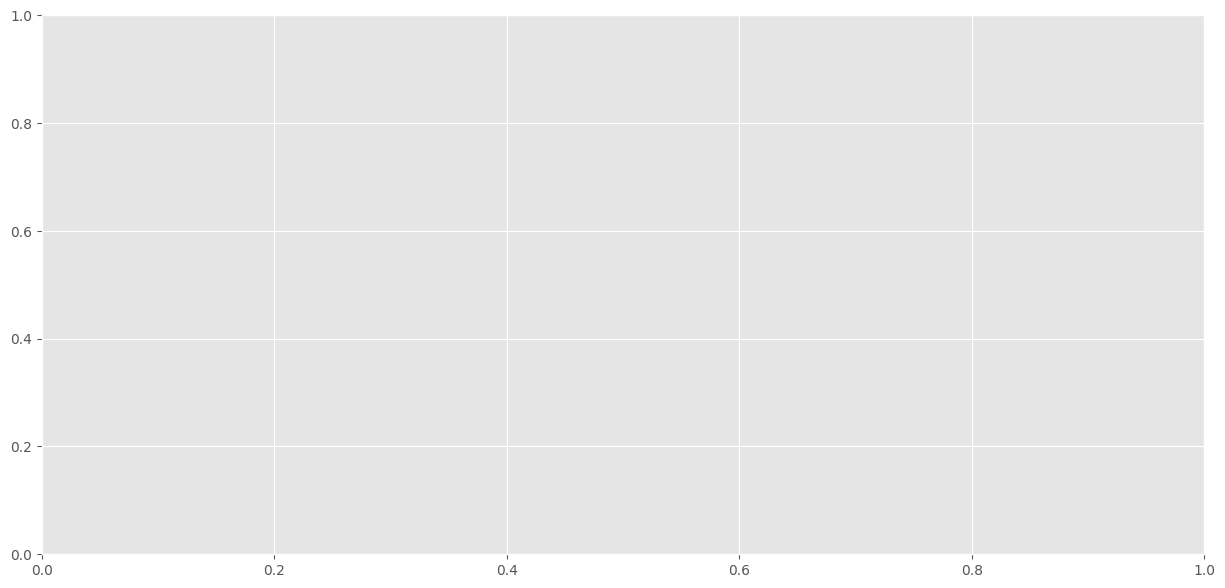

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))
col_to_plot = "MLOG10P"
df[col_to_plot] = -np.log10(df["P"])
#plot the variants with their LD score to the lead variant
p=ax.scatter(df["POS"], df[col_to_plot], c=ld2[df["P"].idxmin()])
#show the lead variant
lead_x, lead_y = df.loc[df["P"].idxmin(), "POS"], df.loc[df["P"].idxmin(), col_to_plot]
ax.annotate(f"Lead Variant: {df.loc[df['P'].idxmin(), 'SNPID']}", 
            (lead_x, lead_y), 
            textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12)

#plot the causal variant
ax.scatter(df.loc[(df["CHR"]==2)&(df["POS"]==55620927),"POS"],df.loc[(df["CHR"]==2)&(df["POS"]==55620927),col_to_plot],
           marker='x',s=40,c="red",label="Causal")

#plot circles around variants in credible sets
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = df.loc[np.array(cs_index)-1, "POS"]
    y = df.loc[np.array(cs_index)-1, col_to_plot]
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolor="green")



plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((55400000, 55800000))
plt.legend()
plt.show()

In [ ]:
wget ftp://ftp.ncbi.nih.gov/snp/latest_release/VCF/GCF_000001405.25.gz -O dbsnp_151_GRCh37.vcf.gz



bcftools index ALL.chr16.vcf.gz

bcftools annotate -a dbsnp_151_GRCh37.vcf.gz -c ID -O z -o annotated_chr16.vcf.gz ALL.chr16.vcf.gz


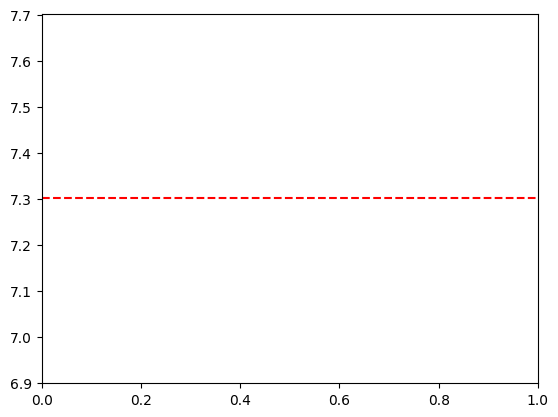

In [ ]:
plt.axhline(y=-np.log10(5e-8), color='red', linestyle='--')
plt.show()

In [ ]:
minor_df.plt(skip=2,anno=True)

AttributeError: 'DataFrame' object has no attribute 'plt'

In [ ]:
sumstatus.plot_mqq(mode="r", anno=True, region=(2,54513738,56513738), region_grid=True, build='hg19')

UnboundLocalError: local variable 'snpid' referenced before assignment

In [ ]:
# gl.download_ref("1kg_eas_hg19")

2025/01/21 22:15:42 Start to download  1kg_eas_hg19  ...
2025/01/21 22:15:42  -Downloading to: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2025/01/21 22:15:42  -File /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz exists.
2025/01/21 22:15:49  -File path: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2025/01/21 22:15:49  -MD5 check: c8c97434843c0da3113fc06879ead472
2025/01/21 22:15:49  -MD5 verified.
2025/01/21 22:15:49  -Updating record in config file...
2025/01/21 22:15:49  -File /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi exists.
2025/01/21 22:15:49  -Updating record in config file...
2025/01/21 22:15:49  -Downloading to: /home/icog-bioai/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi
2025/01/21 22:15:49 Downloaded  1kg_eas_hg19  successfully!


2025/01/21 22:15:58 Start to create MQQ plot...v3.5.5:
2025/01/21 22:15:58  -Genomic coordinates version: 19...
2025/01/21 22:15:58  -Genome-wide significance level to plot is set to 5e-08 ...
2025/01/21 22:15:58  -Raw input contains 907921 variants...
2025/01/21 22:15:58  -MQQ plot layout mode is : r
2025/01/21 22:15:58  -Region to plot : chr2:54531536-56731536.
2025/01/21 22:15:58  -Checking chromosome notations in VCF/BCF files...
2025/01/21 22:15:58  -Checking prefix for chromosomes in VCF/BCF files...
2025/01/21 22:15:58  -No prefix for chromosomes in the VCF/BCF files.
2025/01/21 22:15:58  -Extract SNPs in region : chr2:54531536-56731536...
2025/01/21 22:15:58  -Extract SNPs in specified regions: 795
2025/01/21 22:15:58 Finished loading specified columns from the sumstats.
2025/01/21 22:15:58 Start data conversion and sanity check:
2025/01/21 22:15:58  -Removed 0 variants with nan in CHR or POS column ...
2025/01/21 22:15:58  -Removed 0 variants with CHR <=0...
2025/01/21 22:15:5

2025/01/21 22:26:43  -Retrieving index...
2025/01/21 22:26:43  -Ref variants in the region: 71908
2025/01/21 22:26:43  -Matching variants using POS, NEA, EA ...
2025/01/21 22:26:43  -Calculating Rsq...
2025/01/21 22:26:43 Finished loading reference genotype successfully!
2025/01/21 22:26:43  -Creating background plot...
2025/01/21 22:26:43  -Extracting lead variant...
2025/01/21 22:26:44  -Loading gtf files from:default


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_name', 'gene_biotype']


2025/01/21 22:27:21  -plotting gene track..
2025/01/21 22:27:21  -plotting genes: 14..
2025/01/21 22:27:21  -plotting exons: 1044..
2025/01/21 22:27:21  -Finished plotting gene track..


2025/01/21 22:27:22 Finished creating MQQ plot successfully!
2025/01/21 22:27:22 Start to extract variants for annotation...
2025/01/21 22:27:22  -Found 1 significant variants with a sliding window size of 500 kb...
2025/01/21 22:27:22 Finished extracting variants for annotation...
2025/01/21 22:27:22 Start to process figure arts.
2025/01/21 22:27:22  -Processing X labels...
2025/01/21 22:27:22  -Processing Y labels...
2025/01/21 22:27:22  -Processing Y tick lables...
2025/01/21 22:27:22  -Processing Y labels...
2025/01/21 22:27:22  -Processing color bar...
2025/01/21 22:27:22  -Processing lines...
2025/01/21 22:27:22 Finished processing figure arts.
2025/01/21 22:27:22 Start to annotate variants...
2025/01/21 22:27:22  -Annotating using column CHR:POS...
2025/01/21 22:27:22  -Adjusting text positions with repel_force=0.03...
2025/01/21 22:27:22 Finished annotating variants.
2025/01/21 22:27:22 Start to save figure...
2025/01/21 22:27:22  -Skip saving figure!
2025/01/21 22:27:22 Finish

(<Figure size 3000x2000 with 4 Axes>, <gwaslab.g_Log.Log at 0x7244ee19fa30>)

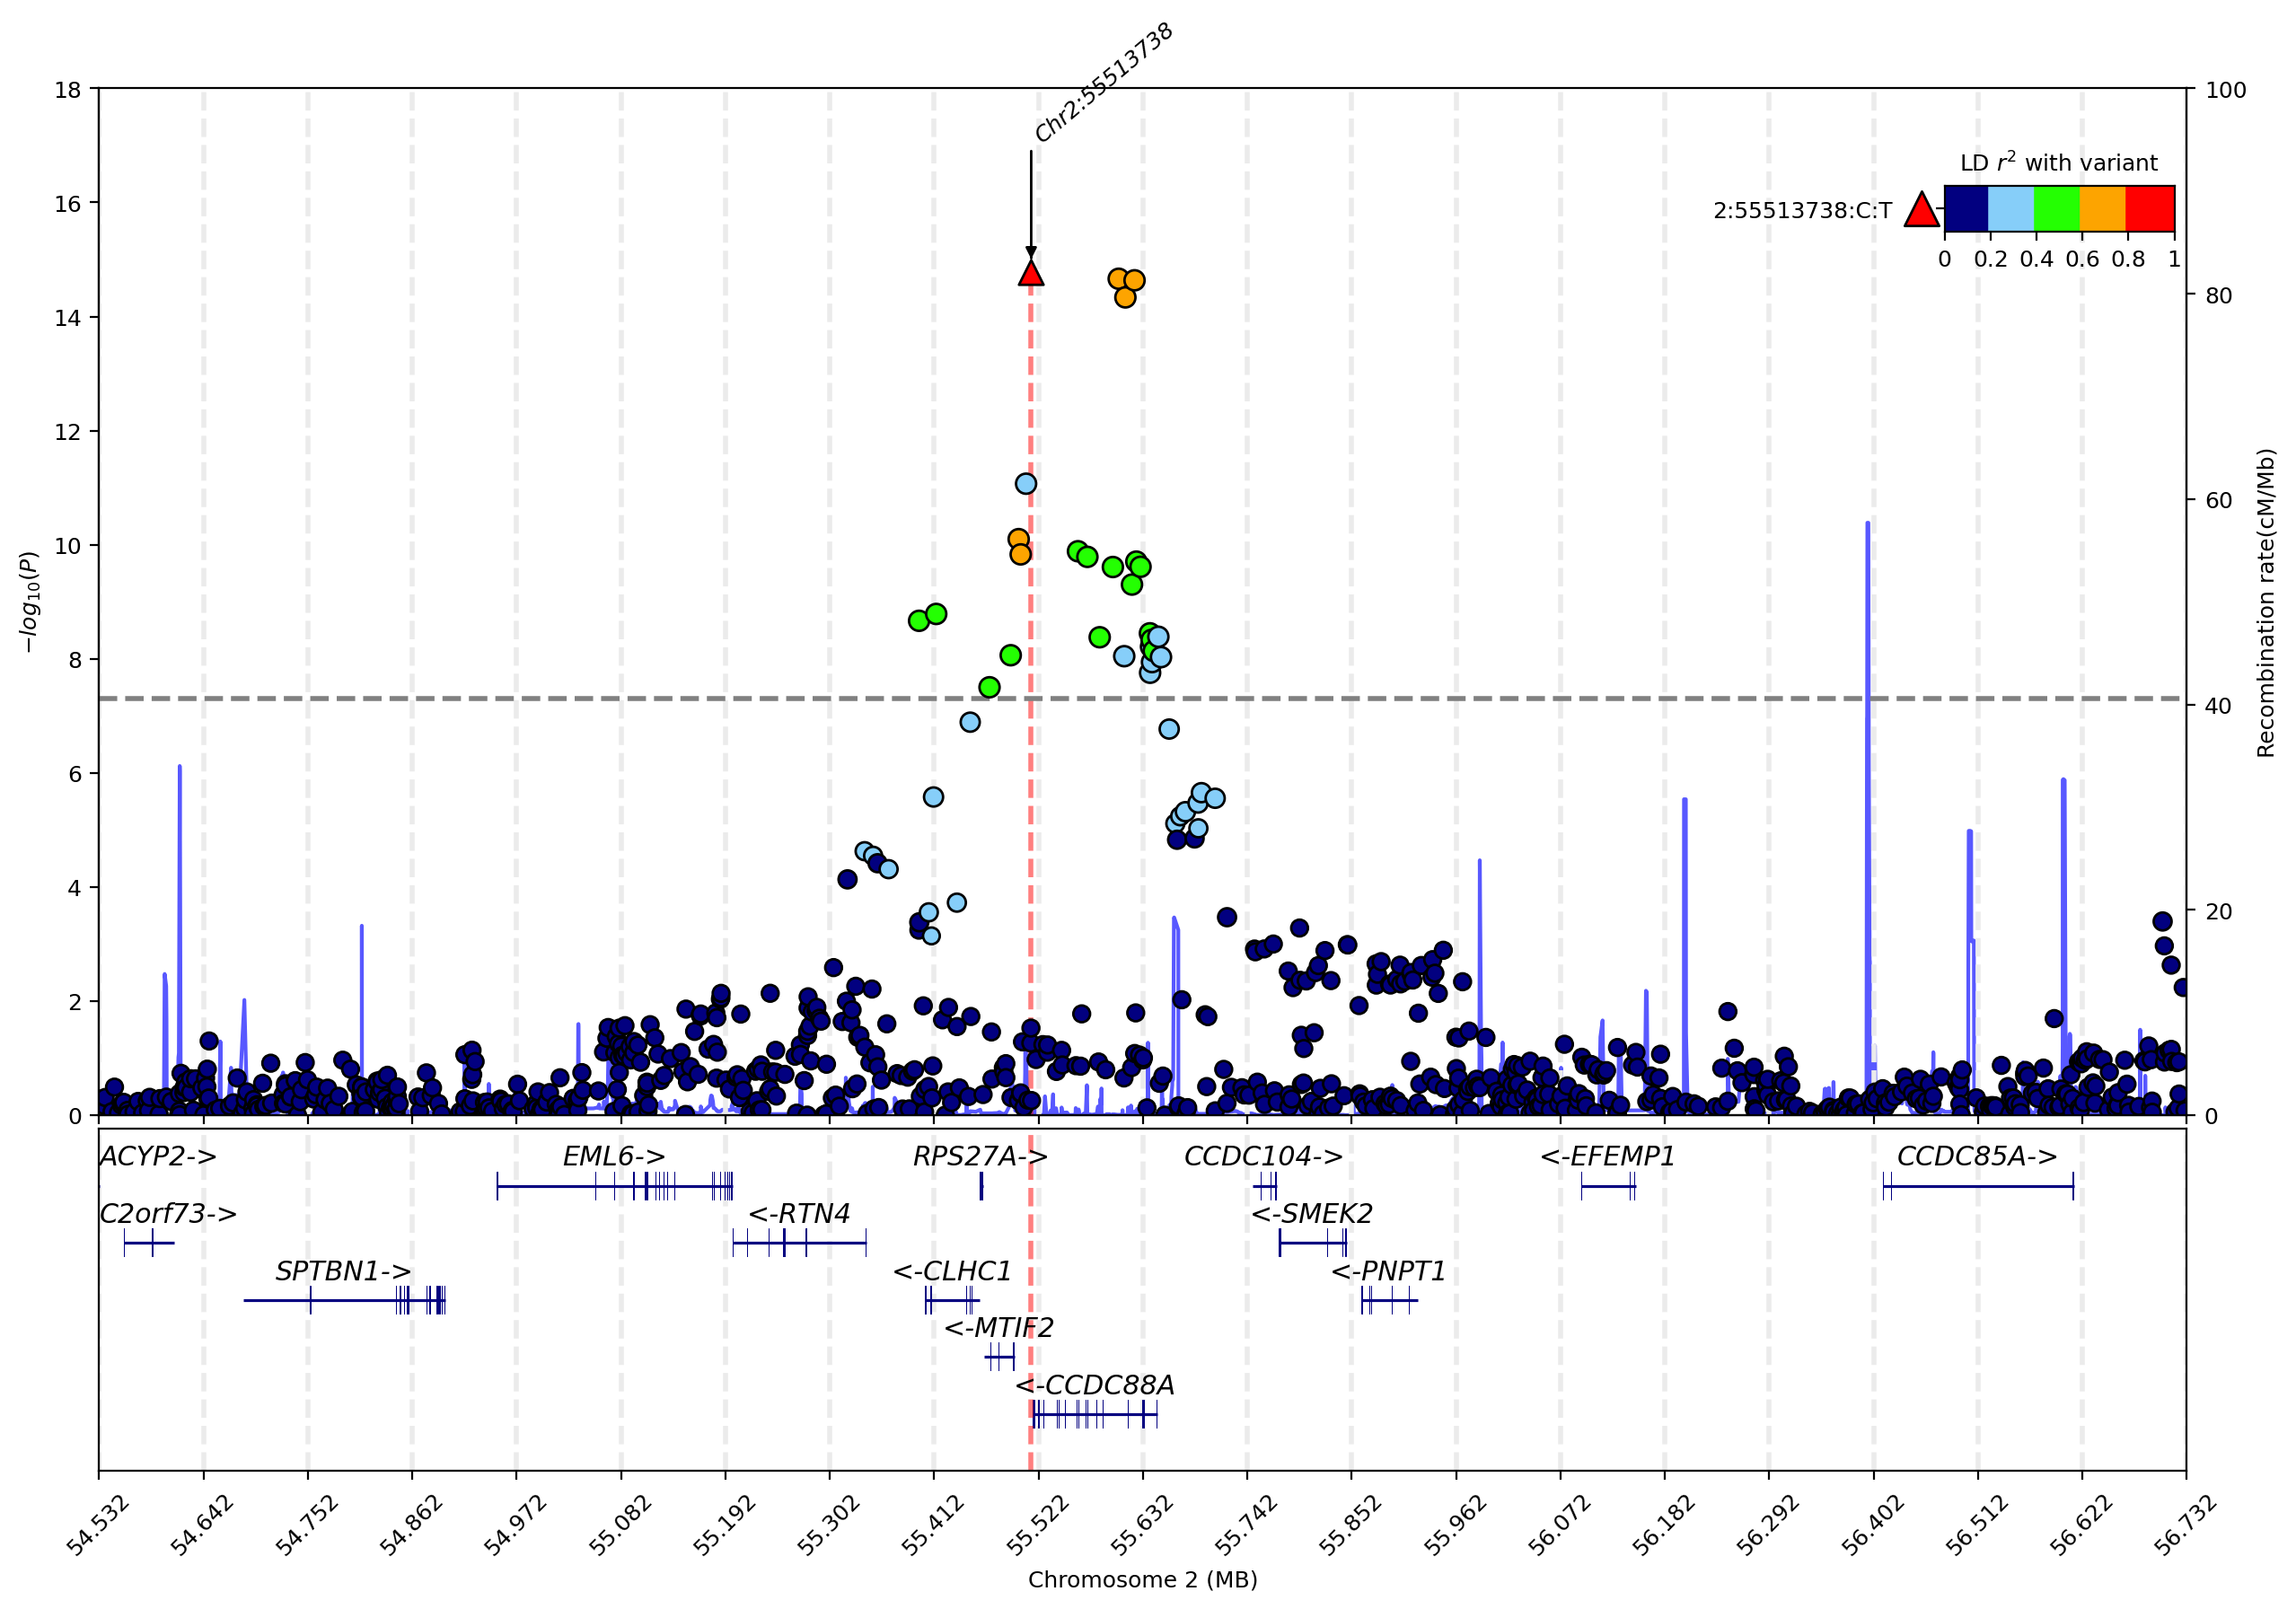

In [ ]:
# sumstatus.plot_mqq(mode="r",anno=True,region=(2,54531536,56731536),region_grid=True,vcf_path=gl.get_path("1kg_eas_hg19"),build="19")